In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
credit_risk = pd.read_csv(r"C:\Users\SHREYA PAI\Files\credit_risk_dataset.csv")

In [3]:
credit_risk.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
credit_risk.shape

(32581, 12)

In [5]:
credit_risk.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [6]:
credit_risk_copy = credit_risk.copy()

In [7]:
credit_risk.pivot_table(index='person_age', columns='loan_status', values='person_income', aggfunc='count').reset_index().sort_values(by='person_age', ascending=False)

loan_status,person_age,0,1
57,144,3.0,NaN
56,123,2.0,NaN
55,94,1.0,NaN
54,84,1.0,NaN
53,80,1.0,NaN
52,78,1.0,NaN
51,76,1.0,NaN
50,73,3.0,NaN
49,70,5.0,2.0
48,69,5.0,NaN


In [8]:
cr_age_rmvd = credit_risk[credit_risk['person_age']<=70]
cr_age_rmvd.reset_index(drop=True, inplace=True)

In [9]:
display(cr_age_rmvd.shape)
display(cr_age_rmvd.head())

(32568, 12)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [10]:
cr_age_rmvd.pivot_table(index='person_emp_length', columns='loan_status', values='person_income', aggfunc='count').reset_index().sort_values(by='person_emp_length', ascending=False)

loan_status,person_emp_length,0,1
34,123.0,1.0,1.0
33,38.0,1.0,NaN
32,34.0,NaN,1.0
31,31.0,4.0,NaN
30,30.0,1.0,1.0
29,29.0,NaN,1.0
28,28.0,3.0,NaN
27,27.0,4.0,1.0
26,26.0,5.0,1.0
25,25.0,8.0,NaN


In [11]:
cr_emp_length_rmvd = cr_age_rmvd[cr_age_rmvd['person_emp_length']<=47]
cr_emp_length_rmvd.reset_index(drop=True, inplace=True)

In [12]:
display(cr_emp_length_rmvd.shape)
display(cr_emp_length_rmvd.head())

(31671, 12)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2


In [13]:
cr_emp_length_rmvd.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,31671.000000,3.167100e+04,31671.000000,31671.000000,28626.000000,31671.000000,31671.000000,31671.000000
mean,27.717754,6.649231e+04,4.780714,9660.637492,11.040070,0.215497,0.169621,5.804395
std,6.159859,5.277413e+04,4.028718,6334.716643,3.229507,0.411173,0.106275,4.048776
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.936600e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.600000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,8.000000e+04,7.000000,12500.000000,13.480000,0.000000,0.230000,8.000000
max,70.000000,2.039784e+06,38.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [14]:
cr_emp_length_rmvd.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length                0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3045
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [15]:
cr_data = cr_emp_length_rmvd.copy()

In [16]:
cr_data.fillna({'loan_int_rate':cr_data['loan_int_rate'].median()}, inplace=True)

In [17]:
cr_data.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [18]:
cr_data.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,31671.000000,3.167100e+04,31671.000000,31671.000000,31671.000000,31671.000000,31671.000000,31671.000000
mean,27.717754,6.649231e+04,4.780714,9660.637492,11.035256,0.215497,0.169621,5.804395
std,6.159859,5.277413e+04,4.028718,6334.716643,3.070364,0.411173,0.106275,4.048776
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.936600e+04,2.000000,5000.000000,8.490000,0.000000,0.090000,3.000000
50%,26.000000,5.600000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,8.000000e+04,7.000000,12500.000000,13.160000,0.000000,0.230000,8.000000
max,70.000000,2.039784e+06,38.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [19]:
cr_data.groupby('loan_status').count()['person_age']

loan_status
0    24846
1     6825
Name: person_age, dtype: int64

In [20]:
cr_data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2


In [21]:
cr_data.groupby('person_home_ownership').count()['loan_intent']

person_home_ownership
MORTGAGE    13088
OTHER         107
OWN          2410
RENT        16066
Name: loan_intent, dtype: int64

In [22]:
cr_data.groupby('loan_intent').count()['person_home_ownership']

loan_intent
DEBTCONSOLIDATION    5064
EDUCATION            6288
HOMEIMPROVEMENT      3510
MEDICAL              5891
PERSONAL             5365
VENTURE              5553
Name: person_home_ownership, dtype: int64

In [23]:
cr_data.groupby('loan_grade').count()['person_home_ownership']

loan_grade
A    10365
B    10181
C     6318
D     3555
E      952
F      236
G       64
Name: person_home_ownership, dtype: int64

In [24]:
cr_data_copy = cr_data.drop('loan_grade', axis=1)

In [25]:
display(cr_data_copy.shape)
display(cr_data_copy.head())

(31671, 11)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,21,9600,OWN,5.0,EDUCATION,1000,11.14,0,0.10,N,2
1,25,9600,MORTGAGE,1.0,MEDICAL,5500,12.87,1,0.57,N,3
2,23,65500,RENT,4.0,MEDICAL,35000,15.23,1,0.53,N,2
3,24,54400,RENT,8.0,MEDICAL,35000,14.27,1,0.55,Y,4
4,21,9900,OWN,2.0,VENTURE,2500,7.14,1,0.25,N,2


**Categorical Features Treatment**

In [26]:
cr_data_cat_treated = cr_data_copy.copy()

In [27]:
cr_data_cat_treated.groupby('person_home_ownership').count()['person_age']

person_home_ownership
MORTGAGE    13088
OTHER         107
OWN          2410
RENT        16066
Name: person_age, dtype: int64

In [28]:
person_home_ownership = pd.get_dummies(cr_data_cat_treated['person_home_ownership'], drop_first=True).astype(int)
person_loan_intent = pd.get_dummies(cr_data_cat_treated['loan_intent'], drop_first=True).astype(int)
cr_data_cat_treated['cb_person_default_on_file_binary'] = np.where(cr_data_cat_treated['cb_person_default_on_file']=='Y', 1, 0)
cr_data_cat_treated.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,cb_person_default_on_file_binary
0,21,9600,OWN,5.0,EDUCATION,1000,11.14,0,0.10,N,2,0
1,25,9600,MORTGAGE,1.0,MEDICAL,5500,12.87,1,0.57,N,3,0
2,23,65500,RENT,4.0,MEDICAL,35000,15.23,1,0.53,N,2,0
3,24,54400,RENT,8.0,MEDICAL,35000,14.27,1,0.55,Y,4,1
4,21,9900,OWN,2.0,VENTURE,2500,7.14,1,0.25,N,2,0


In [29]:
display(person_home_ownership)
display(person_loan_intent)

,OTHER,OWN,RENT
0,0,1,0
1,0,0,0
2,0,0,1
3,0,0,1
4,0,1,0
...,...,...,...
31666,0,0,0
31667,0,0,0
31668,0,0,1
31669,0,0,0


,EDUCATION,HOMEIMPROVEMENT,MEDICAL,PERSONAL,VENTURE
0,1,0,0,0,0
1,0,0,1,0,0
2,0,0,1,0,0
3,0,0,1,0,0
4,0,0,0,0,1
...,...,...,...,...,...
31666,0,0,0,1,0
31667,0,0,0,1,0
31668,0,1,0,0,0
31669,0,0,0,1,0


In [30]:
data_to_scale = cr_data_cat_treated.drop(['person_home_ownership', 'loan_intent', 'loan_status', 'cb_person_default_on_file', 'cb_person_default_on_file_binary'], axis=1)

In [31]:
data_to_scale.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
0,21,9600,5.0,1000,11.14,0.10,2
1,25,9600,1.0,5500,12.87,0.57,3
2,23,65500,4.0,35000,15.23,0.53,2
3,24,54400,8.0,35000,14.27,0.55,4
4,21,9900,2.0,2500,7.14,0.25,2


In [32]:
scaler = StandardScaler()

In [33]:
data_to_scale.columns

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'],
      dtype='object')

In [34]:
scaled_data = scaler.fit_transform(data_to_scale)
scaled_data

array([[-1.09058679, -1.07805103,  0.05443152, ...,  0.03411508,
        -0.655113  , -0.93965566],
       [-0.44121099, -1.07805103, -0.93845588, ...,  0.59757502,
         3.76746129, -0.69266353],
       [-0.76589889, -0.01880318, -0.19379033, ...,  1.36622557,
         3.39107199, -0.93965566],
       ...,
       [ 6.05254702,  0.18016109, -0.44201218, ..., -0.01473982,
         2.73239071,  5.48213962],
       [ 4.59145147,  1.58238543,  0.05443152, ...,  0.14485288,
        -0.655113  ,  4.98815537],
       [ 6.21489097, -0.46410415, -0.69023403, ..., -0.34043921,
        -0.18462637,  5.97612388]], shape=(31671, 7))

In [35]:
scaled_df = pd.DataFrame(scaled_data, columns=['person_age', 'person_income', 'person_emp_length', 'loan_amnt','loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'])
scaled_df.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
0,-1.090587,-1.078051,0.054432,-1.367192,0.034115,-0.655113,-0.939656
1,-0.441211,-1.078051,-0.938456,-0.656810,0.597575,3.767461,-0.692664
2,-0.765899,-0.018803,-0.193790,4.000141,1.366226,3.391072,-0.939656
3,-0.603555,-0.229137,0.799097,4.000141,1.053554,3.579267,-0.445671
4,-1.090587,-1.072366,-0.690234,-1.130398,-1.268682,0.756347,-0.939656


In [36]:
scaled_df.shape

(31671, 7)

In [37]:
scaled_data_combined = pd.concat([scaled_df, person_home_ownership, person_loan_intent], axis=1)
scaled_data_combined['cb_person_default_on_file'] = cr_data_cat_treated['cb_person_default_on_file_binary']
scaled_data_combined['loan_status'] = cr_data_cat_treated['loan_status']

In [38]:
scaled_data_combined.shape

(31671, 17)

In [39]:
scaled_data_combined.groupby('loan_status').count()['EDUCATION']

loan_status
0    24846
1     6825
Name: EDUCATION, dtype: int64

In [40]:
target = scaled_data_combined['loan_status']
features = scaled_data_combined.drop('loan_status', axis=1)
features

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,OTHER,OWN,RENT,EDUCATION,HOMEIMPROVEMENT,MEDICAL,PERSONAL,VENTURE,cb_person_default_on_file
0,-1.090587,-1.078051,0.054432,-1.367192,0.034115,-0.655113,-0.939656,0,1,0,1,0,0,0,0,0
1,-0.441211,-1.078051,-0.938456,-0.656810,0.597575,3.767461,-0.692664,0,0,0,0,0,1,0,0,0
2,-0.765899,-0.018803,-0.193790,4.000141,1.366226,3.391072,-0.939656,0,0,1,0,0,1,0,0,0
3,-0.603555,-0.229137,0.799097,4.000141,1.053554,3.579267,-0.445671,0,0,1,0,0,1,0,0,1
4,-1.090587,-1.072366,-0.690234,-1.130398,-1.268682,0.756347,-0.939656,0,1,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31666,4.753795,-0.255665,-0.938456,-0.609451,0.692028,-0.561016,5.976124,0,0,0,0,0,0,1,0,0
31667,4.266764,1.013916,-0.193790,1.257276,-1.154688,-0.184626,3.259210,0,0,0,0,0,0,1,0,0
31668,6.052547,0.180161,-0.442012,4.000141,-0.014740,2.732391,5.482140,0,0,1,0,1,0,0,0,0
31669,4.591451,1.582385,0.054432,0.842886,0.144853,-0.655113,4.988155,0,0,0,0,0,0,1,0,0


**Data Balancing & Model Training**

In [41]:
!pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [43]:
np.random.seed(42)

In [44]:
from imblearn.over_sampling import SMOTE

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier

In [46]:
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [47]:
smote = SMOTE(random_state=42)

In [48]:
x_train_balanced, y_train_balanced = smote.fit_resample(x_train, y_train)

In [49]:
y_train_balanced_df = pd.DataFrame({'target': y_train_balanced})
y_train_balanced_df.groupby('target').size()

target
0    19862
1    19862
dtype: int64

**Model Training**

***Logistic Regression***

In [50]:
logit = LogisticRegression()

In [51]:
logit.fit(x_train_balanced, y_train_balanced)

LogisticRegression()

***Random Forest***

In [52]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=50,
    min_samples_split=100,
    random_state=42
)

In [53]:
rf.fit(x_train_balanced, y_train_balanced)

RandomForestClassifier(max_depth=6, min_samples_leaf=50, min_samples_split=100,
                       n_estimators=200, random_state=42)

***XGBoost***

In [54]:
xgb = XGBClassifier(
    tree_method = 'exact',
    max_depth=3,
    learning_rate=0.03,
    n_estimators=300,
    subsample=0.7,
    reg_lambda=5,
    reg_alpha=1,
    random_state=42
)

In [55]:
xgb.fit(x_train_balanced, y_train_balanced.values.ravel())

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

**Calibration & Evaluation**

***Logistic Regression***

In [56]:
logit_calibrated=CalibratedClassifierCV(logit, method='sigmoid', cv='prefit')
logit_calibrated.fit(x_train_balanced, y_train_balanced)

C:\Users\SHREYA PAI\AppData\Roaming\Python\Python312\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


CalibratedClassifierCV(cv='prefit', estimator=LogisticRegression())

In [57]:
import pickle

In [58]:
with open('logisticPDModel.pkl','wb') as file:
    pickle.dump(logit_calibrated, file)

In [59]:
logit_calibrated.score(x_train_balanced, y_train_balanced)

0.7842110562883899

In [60]:
y_prob_logit = np.round(logit_calibrated.predict_proba(x_test)[:, 1], 2)
y_prob_logit

array([0.03, 0.65, 0.13, ..., 0.78, 0.03, 0.76], shape=(6335,))

In [61]:
logit_prediction = logit_calibrated.predict(x_test)
logit_prediction

array([0, 1, 0, ..., 1, 0, 1], shape=(6335,))

***Random Forest***

In [62]:
rf_calibrated=CalibratedClassifierCV(rf, method='sigmoid', cv='prefit')
rf_calibrated.fit(x_train_balanced, y_train_balanced)

C:\Users\SHREYA PAI\AppData\Roaming\Python\Python312\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


CalibratedClassifierCV(cv='prefit',
                       estimator=RandomForestClassifier(max_depth=6,
                                                        min_samples_leaf=50,
                                                        min_samples_split=100,
                                                        n_estimators=200,
                                                        random_state=42))

In [63]:
with open('RandomForestPDModel.pkl','wb') as file:
    pickle.dump(rf_calibrated, file)

In [64]:
rf_calibrated.score(x_train_balanced, y_train_balanced)

0.8319907360789447

In [65]:
y_prob_rf = np.round(rf_calibrated.predict_proba(x_test)[:, 1], 2)
y_prob_rf

array([0.08, 0.59, 0.37, ..., 0.67, 0.06, 0.86], shape=(6335,))

In [66]:
rf_prediction = rf_calibrated.predict(x_test)
rf_prediction

array([0, 1, 0, ..., 1, 0, 1], shape=(6335,))

***XgBoost Model***

In [67]:
xgb_calibrated=CalibratedClassifierCV(xgb, method='sigmoid', cv='prefit')
xgb_calibrated.fit(x_train_balanced, y_train_balanced)

C:\Users\SHREYA PAI\AppData\Roaming\Python\Python312\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


CalibratedClassifierCV(cv='prefit',
                       estimator=XGBClassifier(base_score=None, booster=None,
                                               callbacks=None,
                                               colsample_bylevel=None,
                                               colsample_bynode=None,
                                               colsample_bytree=None,
                                               device=None,
                                               early_stopping_rounds=None,
                                               enable_categorical=False,
                                               eval_metric=None,
                                               feature_types=None,
                                               feature_weights=None, gamma=None,
                                               grow_policy=None,
                                               importance_type=None,
                                               interaction_constraints=None,
                                               learning_rate=0.03, max_bin=None,
                                               max_cat_threshold=None,
                                               max_cat_to_onehot=None,
                                               max_delta_step=None, max_depth=3,
                                               max_leaves=None,
                                               min_child_weight=None,
                                               missing=nan,
                                               monotone_constraints=None,
                                               multi_strategy=None,
                                               n_estimators=300, n_jobs=None,
                                               num_parallel_tree=None, ...))

In [68]:
with open('XGBoostPDModel.pkl','wb') as file:
    pickle.dump(xgb_calibrated, file)

In [69]:
xgb_calibrated.score(x_train_balanced, y_train_balanced.ravel())

C:\Users\SHREYA PAI\AppData\Local\Temp\ipykernel_11648\1311084368.py:1: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  xgb_calibrated.score(x_train_balanced, y_train_balanced.ravel())


0.8800221528546974

In [70]:
y_prob_xgb = np.round(xgb_calibrated.predict_proba(x_test)[:, 1], 2)
y_prob_xgb

array([0.03, 0.37, 0.05, ..., 0.43, 0.03, 0.91], shape=(6335,))

In [71]:
xgb_prediction = xgb_calibrated.predict(x_test)
xgb_prediction

array([0, 0, 0, ..., 0, 0, 1], shape=(6335,))

In [72]:
df=pd.DataFrame(y_test)

In [73]:
logit_pd = pd.DataFrame({'logit_pd':y_prob_logit})
rf_pd = pd.DataFrame({'rf_pd':y_prob_rf})
xgb_pd = pd.DataFrame({'xgb_pd':y_prob_xgb})

In [74]:
test_pd = pd.concat([df.reset_index(drop=True), logit_pd, rf_pd, xgb_pd], axis=1)
test_pd.columns=["Actual_status", "Logistic_regression", "Random_forest", "XGBoost"]
test_pd

,Actual_status,Logistic_regression,Random_forest,XGBoost
0,0,0.03,0.08,0.03
1,0,0.65,0.59,0.37
2,0,0.13,0.37,0.05
3,1,0.69,0.96,0.96
4,0,0.33,0.14,0.16
...,...,...,...,...
6330,1,1.00,0.99,0.98
6331,0,0.02,0.04,0.02
6332,0,0.78,0.67,0.43
6333,0,0.03,0.06,0.03


In [78]:
logit_prediction_df = pd.DataFrame({'test_indices_logit': x_test.index, 'logit_pred': logit_prediction})
rf_prediction_df = pd.DataFrame({'test_indices_rf': x_test.index, 'rf_pred': rf_prediction})
xgb_prediction_df = pd.DataFrame({'test_indices_xgb': x_test.index, 'xgb_pred': xgb_prediction})

In [79]:
logit_df = logit_prediction_df.drop(['test_indices_logit'], axis=1)
rf_df = rf_prediction_df.drop(['test_indices_rf'], axis=1)
xgb_df = xgb_prediction_df.drop(['test_indices_xgb'], axis=1)

In [80]:
final_pred_with_NA = pd.concat([cr_data_copy, logit_pd, rf_pd, xgb_pd], axis=1)

**AUC**

In [81]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

In [82]:
auc_logit = round(roc_auc_score(y_test, y_prob_logit), 2)
auc_rf = round(roc_auc_score(y_test, y_prob_rf), 2)
auc_xgb = round(roc_auc_score(y_test, y_prob_xgb), 2)

In [83]:
print("Logistic Regression AUC: ", auc_logit)
print("Random Forest AUC: ", auc_rf)
print("XGBoost AUC: ", auc_xgb)

Logistic Regression AUC:  0.85
Random Forest AUC:  0.9
XGBoost AUC:  0.91


In [84]:
fpr_logit, tpr_logit, _ = roc_curve(y_test, y_prob_logit)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

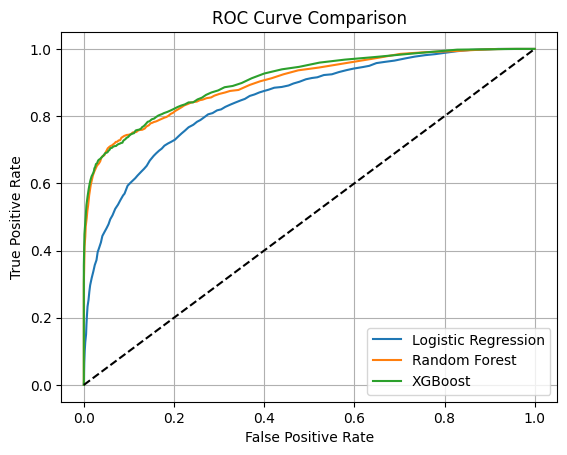

In [85]:
plt.figure()

plt.plot(fpr_logit, tpr_logit, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")

plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.grid()
plt.legend()

plt.show()

**KS**

In [86]:
from scipy.stats import ks_2samp

In [87]:
ks_logit = ks_2samp(y_prob_logit[y_test==1], y_prob_logit[y_test==0]).statistic
ks_rf = ks_2samp(y_prob_rf[y_test==1], y_prob_rf[y_test==0]).statistic
ks_xgb = ks_2samp(y_prob_xgb[y_test==1], y_prob_xgb[y_test==0]).statistic

In [88]:
print("Logistic Regression KS: ", round(ks_logit, 2))
print("Random Forest KS:", round(ks_rf, 2))
print("XGBoost KS:", round(ks_xgb, 2))

Logistic Regression KS:  0.53
Random Forest KS: 0.65
XGBoost KS: 0.65


In [89]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "AUC": [auc_logit, auc_rf, auc_xgb],
    "KS": [round(ks_logit, 2), round(ks_rf, 2), round(ks_xgb, 2)],
    "Average PD": [round(np.mean(logit_pd), 2), round(np.mean(rf_pd), 2), round(np.mean(xgb_pd), 2)]
})

results.reset_index()
results

,Model,AUC,KS,Average PD
0,Logistic Regression,0.85,0.53,0.38
1,Random Forest,0.90,0.65,0.34
2,XGBoost,0.91,0.65,0.29


**Confusion Matrix**

In [90]:
con_mat_logit = confusion_matrix(y_test, logit_prediction)
con_mat_rf = confusion_matrix(y_test, rf_prediction)
con_mat_xgb = confusion_matrix(y_test, xgb_prediction)

In [94]:
cm_logit = pd.DataFrame(
    con_mat_logit,
    index=('Acutal Non-default', 'Actual Default'),
    columns=('Predicted Non-default', 'Predicted Default')
)

cm_logit.index.name = 'Logistic Regression'

cm_logit

,Predicted Non-default,Predicted Default
Logistic Regression,,
Acutal Non-default,3889,1095
Actual Default,334,1017


In [95]:
cm_rf = pd.DataFrame(
    con_mat_rf,
    index=('Acutal Non-default', 'Actual Default'),
    columns=('Predicted Non-default', 'Predicted Default')
)

cm_rf.index.name = 'Randfom Forest'

cm_rf

,Predicted Non-default,Predicted Default
Randfom Forest,,
Acutal Non-default,4304,680
Actual Default,317,1034


In [96]:
cm_xgb = pd.DataFrame(
    con_mat_xgb,
    index=('Acutal Non-default', 'Actual Default'),
    columns=('Predicted Non-default', 'Predicted Default')
)

cm_xgb.index.name = 'XGBoost'

cm_xgb

,Predicted Non-default,Predicted Default
XGBoost,,
Acutal Non-default,4506,478
Actual Default,357,994


**Classification Report**

In [97]:
cr_logit = classification_report(y_test, logit_prediction)
cr_rf = classification_report(y_test, rf_prediction)
cr_xgb = classification_report(y_test, xgb_prediction)

In [98]:
print("Classification Report Logistic Regression \n", cr_logit)

Classification Report Logistic Regression 
               precision    recall  f1-score   support

           0       0.92      0.78      0.84      4984
           1       0.48      0.75      0.59      1351

    accuracy                           0.77      6335
   macro avg       0.70      0.77      0.72      6335
weighted avg       0.83      0.77      0.79      6335



In [99]:
print("Classification Report Random Forest \n", cr_rf)

Classification Report Random Forest 
               precision    recall  f1-score   support

           0       0.93      0.86      0.90      4984
           1       0.60      0.77      0.67      1351

    accuracy                           0.84      6335
   macro avg       0.77      0.81      0.79      6335
weighted avg       0.86      0.84      0.85      6335



In [100]:
print("Classification Report XGBoost \n", cr_xgb)

Classification Report XGBoost 
               precision    recall  f1-score   support

           0       0.93      0.90      0.92      4984
           1       0.68      0.74      0.70      1351

    accuracy                           0.87      6335
   macro avg       0.80      0.82      0.81      6335
weighted avg       0.87      0.87      0.87      6335



**Calibration Table**

In [101]:
test_pd["bin"] = pd.qcut(test_pd["Logistic_regression"], 10, duplicates="drop")

In [102]:
calibration = test_pd.groupby('bin').agg(
    obs=('Actual_status', 'count'),
    defaults=('Actual_status', 'sum'),
    avg_pd_logit=('Logistic_regression', 'mean'),
    avg_pd_rf=('Random_forest', 'mean'),
    avg_pd_xgb=('XGBoost', 'mean')

) 

calibration['observed_dr'] = calibration['defaults'] / calibration['obs']

C:\Users\SHREYA PAI\AppData\Local\Temp\ipykernel_11648\900441965.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calibration = test_pd.groupby('bin').agg(


In [103]:
calibration = calibration.round(2)
calibration = calibration.reset_index()
print("Calibration Table \n")
calibration

Calibration Table 



,bin,obs,defaults,avg_pd_logit,avg_pd_rf,avg_pd_xgb,observed_dr
0,"(-0.001, 0.05]",713,4,0.03,0.08,0.03,0.01
1,"(0.05, 0.1]",645,27,0.08,0.11,0.05,0.04
2,"(0.1, 0.16]",617,42,0.13,0.14,0.07,0.07
3,"(0.16, 0.23]",606,44,0.20,0.17,0.10,0.07
4,"(0.23, 0.32]",638,58,0.28,0.23,0.15,0.09
5,"(0.32, 0.42]",600,83,0.37,0.29,0.21,0.14
6,"(0.42, 0.55]",663,131,0.49,0.38,0.31,0.20
7,"(0.55, 0.69]",597,175,0.62,0.51,0.47,0.29
8,"(0.69, 0.85]",653,305,0.77,0.68,0.67,0.47
9,"(0.85, 1.0]",603,482,0.93,0.90,0.91,0.80


**Feature Importance**

In [104]:
features_copy=features.copy()

In [105]:
logit.coef_[0]

feature_imp_logit = pd.DataFrame({'Feature_LR': x_train_balanced.columns, 'Importance_LR': logit.coef_[0]})

home_ownership_sum_logit=feature_imp_logit[feature_imp_logit['Feature_LR'].isin(['OTHER','OWN','RENT'])]['Importance_LR'].abs().sum()
feature_imp_logit=feature_imp_logit[~feature_imp_logit['Feature_LR'].isin(['OTHER','OWN','RENT'])]
feature_imp_logit=feature_imp_logit.reset_index(drop=True)
feature_imp_logit.loc[len(feature_imp_logit)]=['person_home_ownership', home_ownership_sum_logit]

loan_intent_sum_logit=feature_imp_logit[feature_imp_logit['Feature_LR'].isin(['EDUCATION','HOMEIMPROVEMENT','MEDICAL', 'PERSONAL', 'VENTURE'])]['Importance_LR'].abs().sum()
feature_imp_logit=feature_imp_logit[~feature_imp_logit['Feature_LR'].isin(['EDUCATION','HOMEIMPROVEMENT','MEDICAL', 'PERSONAL', 'VENTURE'])]
feature_imp_logit=feature_imp_logit.reset_index(drop=True)
feature_imp_logit.loc[len(feature_imp_logit)]=['loan_intent', loan_intent_sum_logit]

In [106]:
rf.feature_importances_

feature_imp_rf = pd.DataFrame({'Feature_RF': x_train_balanced.columns, 'Importance_RF': rf.feature_importances_})

home_ownership_sum_rf=feature_imp_rf[feature_imp_rf['Feature_RF'].isin(['OTHER','OWN','RENT'])]['Importance_RF'].abs().sum()
feature_imp_rf=feature_imp_rf[~feature_imp_rf['Feature_RF'].isin(['OTHER','OWN','RENT'])]
feature_imp_rf=feature_imp_rf.reset_index(drop=True)
feature_imp_rf.loc[len(feature_imp_rf)]=['person_home_ownership', home_ownership_sum_rf]

loan_intent_sum_rf=feature_imp_rf[feature_imp_rf['Feature_RF'].isin(['EDUCATION','HOMEIMPROVEMENT','MEDICAL', 'PERSONAL', 'VENTURE'])]['Importance_RF'].abs().sum()
feature_imp_rf=feature_imp_rf[~feature_imp_rf['Feature_RF'].isin(['EDUCATION','HOMEIMPROVEMENT','MEDICAL', 'PERSONAL', 'VENTURE'])]
feature_imp_rf=feature_imp_rf.reset_index(drop=True)
feature_imp_rf.loc[len(feature_imp_rf)]=['loan_intent', loan_intent_sum_rf]

In [107]:
xgb.feature_importances_
feature_imp_xgb = pd.DataFrame({'Feature_XGB': x_train_balanced.columns, 'Importance_XGB': rf.feature_importances_})

home_ownership_sum_xgb=feature_imp_xgb[feature_imp_xgb['Feature_XGB'].isin(['OTHER','OWN','RENT'])]['Importance_XGB'].abs().sum()
feature_imp_xgb=feature_imp_xgb[~feature_imp_xgb['Feature_XGB'].isin(['OTHER','OWN','RENT'])]
feature_imp_xgb=feature_imp_xgb.reset_index(drop=True)
feature_imp_xgb.loc[len(feature_imp_xgb)]=['person_home_ownership', home_ownership_sum_xgb]

loan_intent_sum_xgb=feature_imp_xgb[feature_imp_xgb['Feature_XGB'].isin(['EDUCATION','HOMEIMPROVEMENT','MEDICAL', 'PERSONAL', 'VENTURE'])]['Importance_XGB'].abs().sum()
feature_imp_xgb=feature_imp_xgb[~feature_imp_xgb['Feature_XGB'].isin(['EDUCATION','HOMEIMPROVEMENT','MEDICAL', 'PERSONAL', 'VENTURE'])]
feature_imp_xgb=feature_imp_xgb.reset_index(drop=True)
feature_imp_xgb.loc[len(feature_imp_xgb)]=['loan_intent', loan_intent_sum_xgb]

In [129]:
feature_imp_logit.rename(columns={'Feature_LR': 'Feature', 'Importance_LR': 'Importance'}, inplace=True)
feature_imp_logit['Model']='Logistic Regression'

feature_imp_rf.rename(columns={'Feature_RF': 'Feature', 'Importance_RF': 'Importance'}, inplace=True)
feature_imp_rf['Model']='Random Forest'

feature_imp_xgb.rename(columns={'Feature_XGB': 'Feature', 'Importance_XGB': 'Importance'}, inplace=True)
feature_imp_xgb['Model']='XGBoost'

feature_imp=pd.concat([feature_imp_logit, feature_imp_rf, feature_imp_xgb])

feature_imp['norm_importance']=feature_imp.groupby('Model')['Importance']\
.transform(lambda x: x / x.sum())

feature_imp['rank']=feature_imp.groupby('Model')['norm_importance']\
.rank(ascending=False)

feature_imp_matrix=feature_imp.pivot(index='Feature', columns='Model', values='rank')

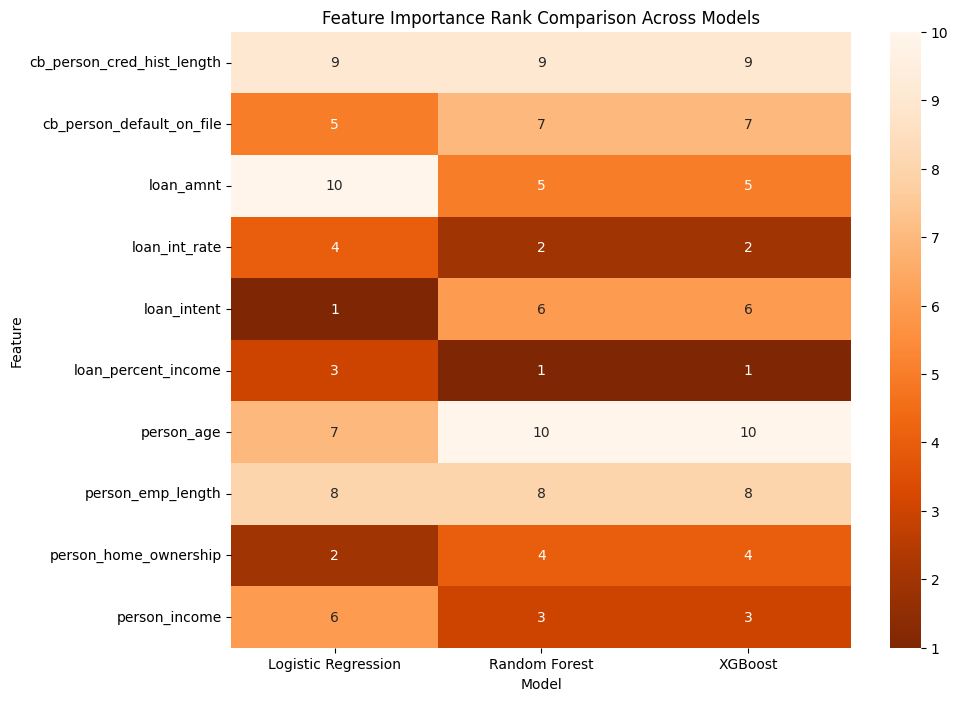

In [130]:
plt.figure(figsize=(10, 8))
sns.heatmap(feature_imp_matrix, annot=True, cmap='Oranges_r')

plt.title("Feature Importance Rank Comparison Across Models")
plt.xlabel("Model")
plt.ylabel("Feature")

plt.show()

**Documentation**

<Axes: xlabel='loan_status', ylabel='loan_percent_income'>

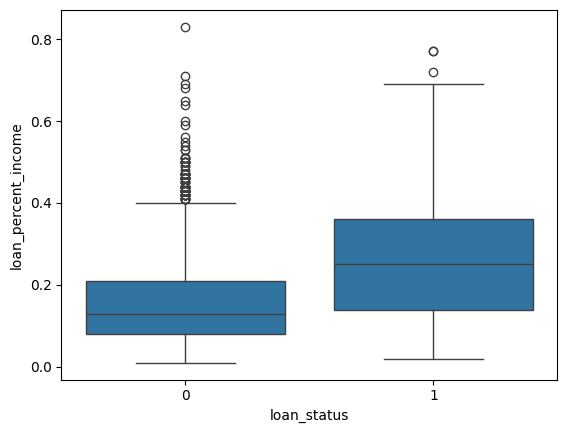

In [131]:
sns.boxplot(x='loan_status', y='loan_percent_income', data=final_pred_with_NA)

<Axes: xlabel='loan_status', ylabel='loan_int_rate'>

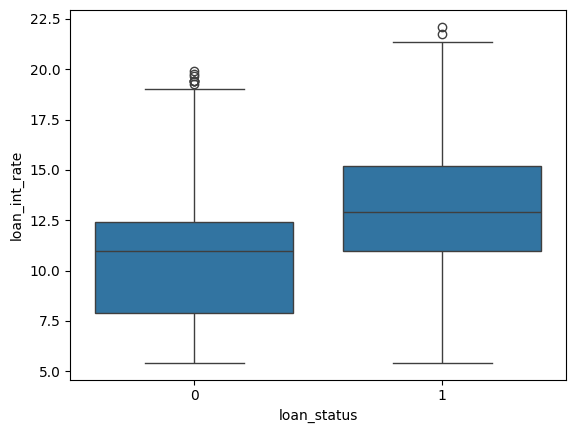

In [132]:
sns.boxplot(x='loan_status', y='loan_int_rate', data=final_pred_with_NA)

<Axes: xlabel='loan_status', ylabel='loan_amnt'>

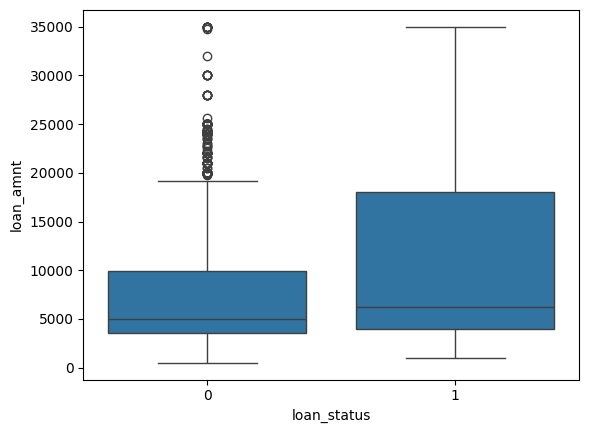

In [133]:
sns.boxplot(x='loan_status', y='loan_amnt', data=final_pred_with_NA)

In [134]:
final_pred_with_NA.to_excel(r"C:\Users\SHREYA PAI\Files\pd_prediction_with_NA.xlsx", index=False)

In [135]:
final_pred_with_NA.dropna(inplace=True)

In [136]:
final_pred_with_NA.shape

(6335, 14)

In [137]:
final_pred_with_NA.to_excel(r"C:\Users\SHREYA PAI\Files\pd_prediction_without_NA.xlsx", index=False)

In [138]:
predictions = pd.concat([df.reset_index(drop=True), logit_df, rf_df, xgb_df], axis=1)
predictions.columns=["Actual_status", "Logistic_regression", "Random_forest", "XGBoost"]

In [139]:
predictions.to_excel(r"C:\Users\SHREYA PAI\Files\test_data_plus_prediction.xlsx", index=False)

In [140]:
calibration.to_excel(r"C:\Users\SHREYA PAI\Files\calibration_table.xlsx", index=False)

In [141]:
results.to_excel(r"C:\Users\SHREYA PAI\Files\AUC_KS_PD.xlsx", index=False)

In [142]:
roc_logit = pd.DataFrame({
    'FPR': fpr_logit,
    'TPR': tpr_logit,
    'Model': 'Logistic Regression'
})   

In [143]:
roc_rf = pd.DataFrame({
    'FPR': fpr_rf,
    'TPR': tpr_rf,
    'Model': 'Random Forest'
})   

In [144]:
roc_xgb = pd.DataFrame({
    'FPR': fpr_xgb,
    'TPR': tpr_xgb,
    'Model': 'XGBoost'
})   

In [145]:
roc_all = pd.concat([roc_logit, roc_rf, roc_xgb])
roc_all = np.round(roc_all, 2)

In [148]:
roc_all.to_excel(r"C:\Users\SHREYA PAI\Files\roc_all.xlsx", index=False)

In [149]:
feature_imp_matrix=feature_imp_matrix.reset_index()

In [150]:
feature_imp_matrix.to_excel(r"C:\Users\SHREYA PAI\Files\Feature_Imp_Matrix.xlsx", index=False)